# Lab 3B: Digital Filtering and Noise Reduction

Run the cells in order. In this lab you will:

1. inspect the imported reference signal and simulated noisy measurement;
2. apply the Nyquist rule to check the provided sampling frequency and calculate the sampling period;
3. select a continuous low-pass-filter cutoff from engineering requirements;
4. implement and verify the corresponding iterative digital filter;
5. evaluate noise reduction and delay; and
6. reflect on the complete workflow and compare other filter types.


## 0. Setup

Keep `Lab3B_reference_signal.csv` and `lab3b_plotting.py` in the same folder as the notebook. Your required work is identified by the numbered TODO items. All other code cells contain provided code and should be run without modification.


In [1]:
# PROVIDED CODE — DO NOT MODIFY THIS CELL.
# Run this cell as written.

import importlib
import numpy as np

import lab3b_plotting as _lab3b_plotting
importlib.reload(_lab3b_plotting)

from lab3b_plotting import (
    plot_candidate_frequency_responses,
    plot_continuous_filter_candidates,
    plot_filter_comparison,
    plot_measurement_and_spectrum,
    plot_step_responses,
)


## 1. Inspect the simulated measurement

Consider an electrical signal that varies slowly and whose main frequencies are below 2 Hz. The measured signal also contains a narrow-band 18 Hz periodic interference and broadband white noise from the measurement electronics. Here, *broadband* means that the random noise energy is spread across a wide range of frequencies rather than concentrated at one frequency.

The noise-free reference signal is imported from `Lab3B_reference_signal.csv`. The notebook then adds the interference and white noise to create the measured signal. In a real experiment, the noise-free reference would normally be unknown.

Run the provided cell and inspect both the time history and amplitude spectrum.


Number of samples: 1000
Sampling period: 0.0100 s
Sampling frequency: 100.0 Hz


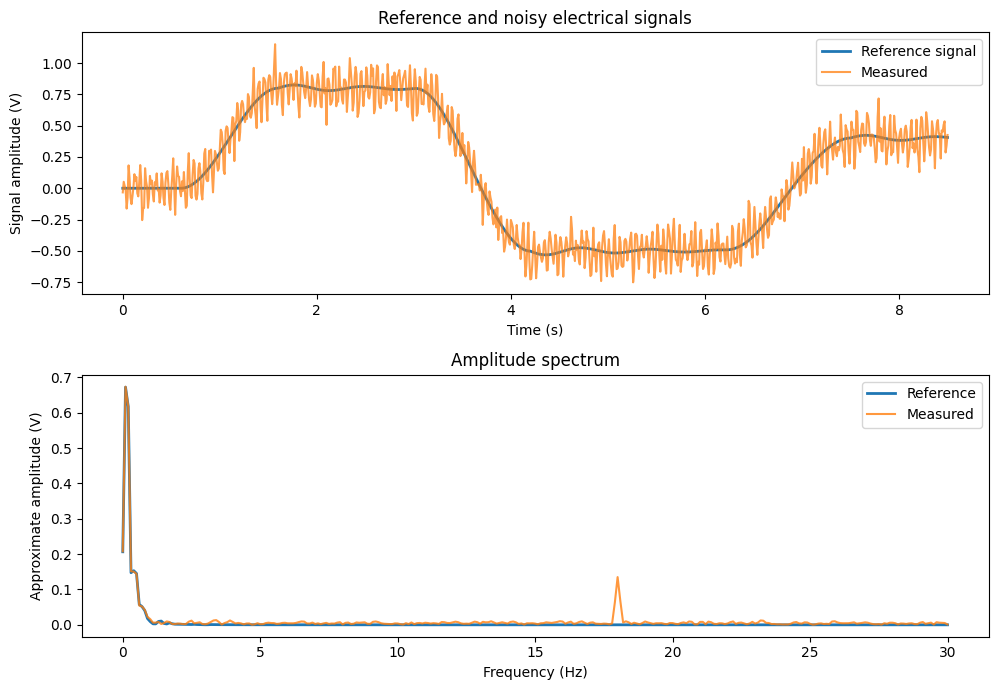

In [2]:
# PROVIDED CODE — DO NOT MODIFY THIS CELL.
# Run this cell as written.

# Load the noise-free reference electrical signal from the provided CSV file.
DATA_FILE = "Lab3B_reference_signal.csv"
reference_data = np.loadtxt(DATA_FILE, delimiter=",", skiprows=1)
t = reference_data[:, 0]
x_clean = reference_data[:, 1]

# Infer the uniform sampling settings from the imported time column.
sample_intervals_s = np.diff(t)
TS_S = float(np.mean(sample_intervals_s))
if not np.allclose(sample_intervals_s, TS_S):
    raise ValueError("The imported time samples must be uniformly spaced.")
FS_HZ = 1.0 / TS_S
DURATION_S = t[-1] + TS_S

# Experiment settings. Do not change these values in Parts 1--5.
RNG_SEED = 418
SIGNAL_BANDWIDTH_HZ = 2.0
INTERFERENCE_FREQUENCY_HZ = 18.0

rng = np.random.default_rng(RNG_SEED)

# Add narrow-band interference and broadband measurement noise.
periodic_interference = 0.14 * np.sin(
    2.0 * np.pi * INTERFERENCE_FREQUENCY_HZ * t + 0.2
)
white_noise = 0.07 * rng.standard_normal(len(t))
x_noise = periodic_interference + white_noise
x_measured = x_clean + x_noise

print(f"Number of samples: {len(t)}")
print(f"Sampling period: {TS_S:.4f} s")
print(f"Sampling frequency: {FS_HZ:.1f} Hz")

plot_measurement_and_spectrum(t, x_clean, x_measured, FS_HZ)


### TODO 1 — Identify the signal and noise

Record your observations below.

- **What frequency range contains most of the useful reference signal?**

  **Response:**  
  <br>

- **What feature identifies the periodic interference, and at what frequency does it occur?**

  **Response:**  
  <br>

- **How does the broadband white noise appear in the amplitude spectrum?**

  **Response:**  
  <br>

- **Why is the amplitude spectrum more useful than the time history for separating these components?**

  **Response:**  
  <br>


## 2. Check the sampling rate

 **Nyquist sampling rule**

$$f_s > 2f_B，$$

where $f_B$ is not simply the highest frequency that you want in the filtered output. It is the highest distinct frequency that the recorded data must represent correctly so that the digital filter can distinguish what to retain from what to attenuate. 



### TODO 2 — Check the sampling settings

Use the amplitude spectrum and the Nyquist rule.

- **Which distinct interference peak must the digital filter reduce? Why must it still be included in the frequency range represented by $f_B$, even though it is unwanted?**

  **Response:**  
  <br>

- **What value do you select for $f_B$?**

  **Response:**  
  <br>

- **What Nyquist threshold $2f_B$ and sampling-rate condition result from your choice?**

  **Response:**  
  <br>

- **Does the provided $f_s=100$ Hz satisfy the condition, and what is the corresponding sampling period $T_s=1/f_s$?**

  **Response:**  
  <br>


## 3. Design the low-pass filter

A first-order low-pass filter mostly preserves signal components below its cutoff frequency $f_c$ and attenuates components above $f_c$.

Its continuous transfer function is

$$H(s)=\frac{1}{\tau s+1}, \qquad \tau=\frac{1}{2\pi f_c}.$$

The frequency-response graph is obtained from this transfer function and is displayed in decibels. The cutoff $f_c$ occurs at $-3$ dB.

The provided code will plot the candidate frequency responses and the corresponding continuously filtered time histories. You do not need to modify the plotting or continuous-simulation code.


The design requirements are:

- At 2 Hz, the magnitude ratio must be **at least 0.90**.
- At the periodic-interference frequency, the magnitude ratio must be **at most 0.30**.

For a first-order low-pass filter, calculate the magnitude ratio at any frequency from

$$
R(f,f_c)=\left|H(j2\pi f)\right|=\frac{1}{\sqrt{1+(f/f_c)^2}}.
$$

The ratio $R$ is the fraction of the input amplitude that remains. Thus, $100R\%$ is retained and $100(1-R)\%$ is reduced.

The next two provided cells show the candidate frequency responses and the corresponding filtered time histories. The frequency-response graph marks each candidate at 2 Hz and at the interference frequency. After inspecting both figures, complete the calculation cell by entering the equation above directly so that the relationship among $f$, $f_c$, and $R$ is visible.


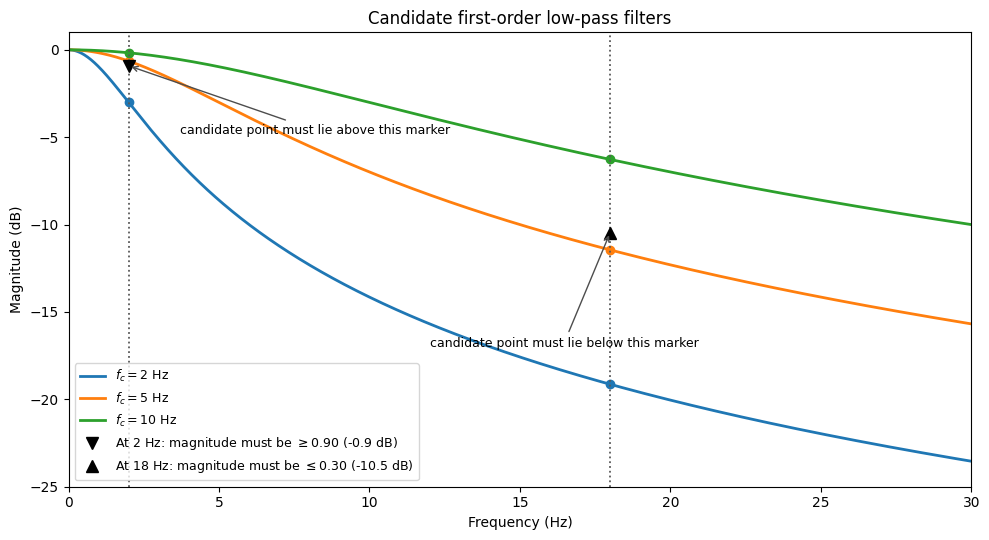

In [3]:
# PROVIDED CODE — DO NOT MODIFY THIS CELL.
# The plotting details are in lab3b_plotting.py.

CANDIDATE_FC_HZ = [2.0, 5.0, 10.0]
MIN_SIGNAL_RATIO = 0.90
MAX_INTERFERENCE_RATIO = 0.30

plot_candidate_frequency_responses(
    CANDIDATE_FC_HZ,
    SIGNAL_BANDWIDTH_HZ,
    INTERFERENCE_FREQUENCY_HZ,
    MIN_SIGNAL_RATIO,
    MAX_INTERFERENCE_RATIO,
)


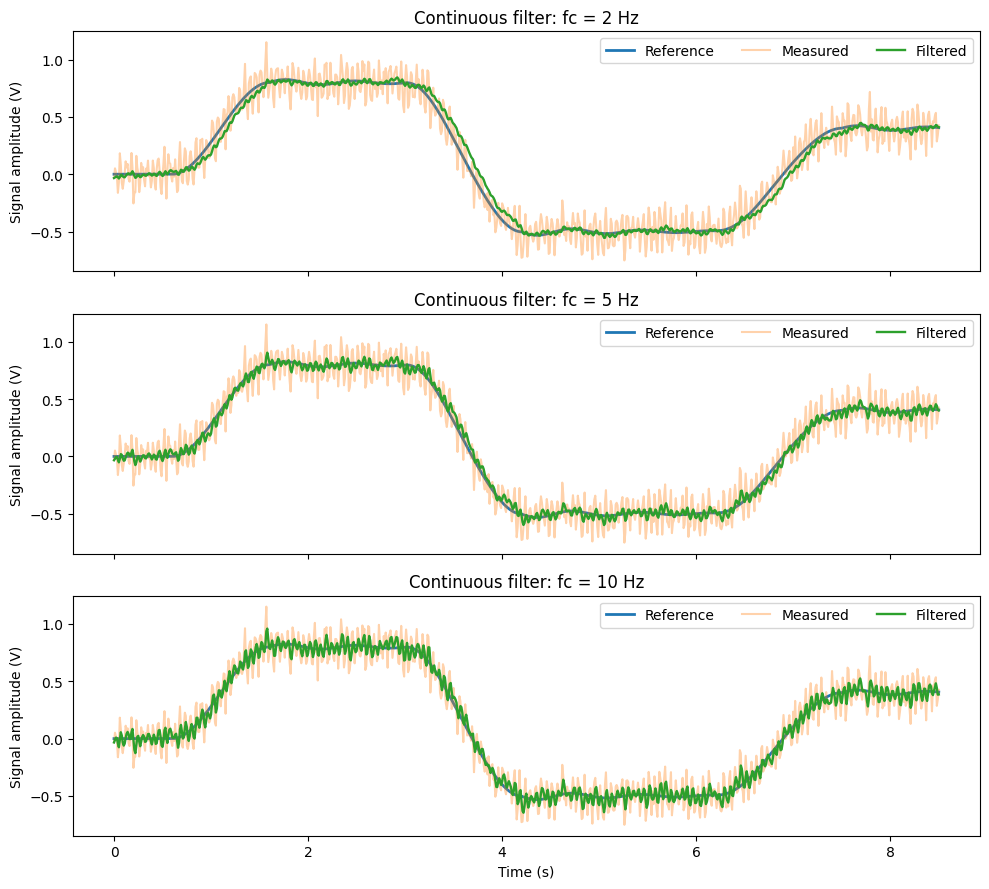

In [4]:
# PROVIDED CODE — DO NOT MODIFY THIS CELL.
# The plotting details are in lab3b_plotting.py.

plot_continuous_filter_candidates(
    t, x_clean, x_measured, CANDIDATE_FC_HZ
)


In [ ]:
# TODO 3a (student): Complete the two magnitude-ratio calculations.
# Enter R = 1/sqrt(1 + (f/fc)^2) directly.

candidate_fc_hz = np.asarray(CANDIDATE_FC_HZ, dtype=float)

# Calculate R at 2 Hz for fc = 2, 5, and 10 Hz.
magnitude_ratio_at_2_hz = None  # TODO: REPLACE None with your calculation.

# Calculate R at 18 Hz for fc = 2, 5, and 10 Hz.
magnitude_ratio_at_18_hz = None  # TODO: REPLACE None with your calculation.

print("Candidate fc values (Hz):  ", candidate_fc_hz)
print("R at 2 Hz:                 ", np.round(magnitude_ratio_at_2_hz, 3))
print("R at 18 Hz:                ", np.round(magnitude_ratio_at_18_hz, 3))


### TODO 3 — Compare the candidates and select $f_c$

Use your calculated ratios together with both figures. The frequency-response graph provides the pass/fail evidence; the time histories show what that choice does to the waveform.

- **For $f_c=2$ Hz, report $R(2~\mathrm{Hz})$ and $R(18~\mathrm{Hz})$. What percentage of the useful 2 Hz amplitude remains, and what percentage of the 18 Hz interference is reduced?**

  **Response:**  
  <br>

- **Repeat these calculations for $f_c=5$ Hz.**

  **Response:**  
  <br>

- **Repeat these calculations for $f_c=10$ Hz.**

  **Response:**  
  <br>

- **Which candidates satisfy the 2 Hz requirement? Which satisfy the 18 Hz requirement? Which candidate satisfies both?**

  **Response:**  
  <br>

- **What useful-signal attenuation or delay do you observe when $f_c$ is too low, and what interference remains when $f_c$ is too high?**

  **Response:**  
  <br>

- **What cutoff frequency do you select? Justify it with evidence from both figures rather than visual smoothness alone.**

  **Response:**  
  <br>


## 4. Implement and verify the digital filter

The optional box in Section 3B.3.4 of the manual shows where the iterative equation comes from. No derivation is required in the notebook. For implementation, use

$$
y[k]=y[k-1]+\alpha\left(x[k]-y[k-1]\right),
$$

where $x[k]$ is the current measurement, $y[k-1]$ is the previous filtered output, and

$$
T_s=\frac{1}{f_s},\qquad
\tau=\frac{1}{2\pi f_c},\qquad
\alpha=\frac{T_s}{\tau+T_s}.
$$

### Required coding task

In TODO 4, first enter the cutoff selected in TODO 3. Then complete `first_order_lowpass()` by calculating `ts`, `tau`, and `alpha` and implementing the iterative update inside the loop.


In [ ]:
# TODO 4a (student): Enter the cutoff frequency selected in TODO 3.
FC_SELECTED_HZ = np.nan


# TODO 4b (student): Complete this function, then run the checks below.
def first_order_lowpass(x, fs_hz, fc_hz):
    """Apply a real-time-style first-order low-pass filter."""
    x = np.asarray(x, dtype=float)

    # TODO 4b (student): Calculate the sample period Ts = 1/fs.
    ts = np.nan

    # TODO 4c (student): Calculate tau = 1/(2*pi*fc).
    tau = np.nan

    # TODO 4d (student): Calculate alpha = Ts/(tau + Ts).
    alpha = np.nan

    # PROVIDED INITIALIZATION — DO NOT MODIFY.
    y = np.zeros_like(x)
    y[0] = x[0]

    for k in range(1, len(x)):
        # TODO 4e (student): Replace the next line with the iterative update.
        y[k] = y[k - 1]

    return y, alpha


In [ ]:
# PROVIDED CODE — DO NOT MODIFY THIS CELL.
# Run this cell as written.

y_digital, alpha_selected = first_order_lowpass(
    x_measured, fs_hz=FS_HZ, fc_hz=FC_SELECTED_HZ
)

expected_tau = 1.0 / (2.0 * np.pi * FC_SELECTED_HZ)
expected_alpha = TS_S / (expected_tau + TS_S)
expected_first_update = (
    x_measured[0]
    + expected_alpha * (x_measured[1] - x_measured[0])
)

checks = {
    "output length": len(y_digital) == len(x_measured),
    "alpha": np.isclose(alpha_selected, expected_alpha),
    "first update": np.isclose(y_digital[1], expected_first_update),
}

for name, passed in checks.items():
    print(f"{name:>14s}: {'PASS' if passed else 'NOT YET'}")

print(f"Calculated alpha: {alpha_selected:.6f}")


In [ ]:
# PROVIDED CODE — DO NOT MODIFY THIS CELL.
# The plotting details are in lab3b_plotting.py.

plot_filter_comparison(
    t, x_clean, x_measured, y_digital, FC_SELECTED_HZ
)


### TODO 4 — Verify the digital-filter implementation

Complete the code, run the automated checks and comparison plot, and record the results.

- **What cutoff frequency did you enter in the implementation cell?**

  **Response:**  
  <br>

- **What values did you calculate for $T_s$, $\tau$, and $\alpha$?**

  **Response:**  
  <br>

- **What did the three automated checks report?**

  **Response:**  
  <br>

- **How closely does the iterative digital result agree with the continuous simulation?**

  **Response:**  
  <br>

- **Does the implemented filter retain the low-frequency reference signal and reduce the periodic interference?**

  **Response:**  
  <br>


## 5. Evaluate noise reduction and delay

A smoother-looking plot is not enough evidence. Because this is a simulation, the clean reference signal is known and the error at sample $k$ can be calculated. The root-mean-square (RMS) error is

$$
e[k]=\hat{x}[k]-x_{\mathrm{ref}}[k],\qquad
e_{\mathrm{RMS}}=\sqrt{\frac{1}{N}\sum_{k=0}^{N-1}e[k]^2}.
$$

Squaring prevents positive and negative errors from canceling, and averaging combines all samples into one measure. RMS error has the same units as the signal; a smaller value means that the estimate is closer to the reference overall. However, RMS alone does not show which frequencies remain or how much delay the filter introduces.

Complete the RMS function in the next cell and pass its check. Then examine the provided step response to evaluate delay.


In [ ]:
# TODO 5a (student): Complete this RMS-error function.
def rms_error(estimate, reference):
    estimate = np.asarray(estimate, dtype=float)
    reference = np.asarray(reference, dtype=float)

    # TODO 5a: Calculate the error at every sample.
    error = None  # TODO: REPLACE None with your calculation.

    # TODO 5b: Calculate the mean of the squared errors.
    mean_squared_error = None  # TODO: REPLACE None with your calculation.

    # TODO 5c: Take the square root and return the RMS error.
    rms = None  # TODO: REPLACE None with your calculation.
    return rms


# PROVIDED CHECK AND CALCULATIONS — DO NOT MODIFY BELOW THIS LINE.
test_rms = rms_error(np.array([0.0, 3.0, 4.0]), np.zeros(3))
expected_test_rms = np.sqrt(25.0 / 3.0)
print(
    "RMS function check:",
    "PASS" if np.isclose(test_rms, expected_test_rms) else "NOT YET",
)


rms_measured = rms_error(x_measured, x_clean)
rms_filtered = rms_error(y_digital, x_clean)

print(f"RMS error before filtering: {rms_measured:.4f}")
print(f"RMS error after filtering:  {rms_filtered:.4f}")


In [ ]:
# PROVIDED CODE — DO NOT MODIFY THIS CELL.
# The calculations remain visible; figure formatting is in lab3b_plotting.py.

def iterative_step_response(fc_hz, fs_hz=FS_HZ, duration_s=1.0):
    step_t = np.arange(0.0, duration_s, 1.0 / fs_hz)
    step_input = np.ones_like(step_t)
    step_input[0] = 0.0
    step_output, _ = first_order_lowpass(step_input, fs_hz, fc_hz)
    return step_t, step_input, step_output


step_results = []
for fc_hz in [2.0, FC_SELECTED_HZ]:
    step_t, step_input, step_output = iterative_step_response(fc_hz)
    threshold_indices = np.flatnonzero(step_output >= 0.90)
    t_90_s = step_t[threshold_indices[0]] if len(threshold_indices) else np.nan
    step_results.append({
        "fc_hz": fc_hz,
        "time_s": step_t,
        "input": step_input,
        "output": step_output,
        "t_90_s": t_90_s,
    })
    print(f"fc={fc_hz:g} Hz: time to reach 90% = {t_90_s:.4f} s")

plot_step_responses(step_results)


### TODO 5 — Evaluate performance

Complete the RMS-error function, run its check and the provided step-response cell, and interpret the results.

- **Did the RMS-function check report `PASS`?**

  **Response:**  
  <br>

- **What is the RMS error before filtering?**

  **Response:**  
  <br>

- **What is the RMS error after filtering?**

  **Response:**  
  <br>

- **Does the smaller RMS error support the conclusion that filtering improved the measurement? What important behavior does this single metric not describe?**

  **Response:**  
  <br>

- **Which cutoff reaches 90% of the step first?**

  **Response:**  
  <br>

- **What happens to delay when the cutoff frequency is reduced from 5 Hz to 2 Hz?**

  **Response:**  
  <br>


## 6. Limitations and other filter choices



### TODO 6 — Reflect on the design workflow

Answer each question in two to four sentences. Focus on engineering reasoning rather than repeating definitions.

1. **Starting with the measured time history, describe the complete chain of evidence and decisions that led to the implemented digital filter. Include the amplitude spectrum, $f_B$, $f_s$, $f_c$, the transfer function, the iterative equation, and verification.**

   **Response:**  
   <br>

2. **Explain the different roles of $f_s$ and $f_c$. Why can one not replace the other?**

   **Response:**  
   <br>

3. **Suppose the sampling frequency changes while the desired continuous cutoff frequency remains the same. Which quantities in the digital implementation must be recalculated, and which continuous-filter quantity remains unchanged?**

   **Response:**  
   <br>

4. **Choose one situation below and identify a more suitable filter type: slow sensor drift, a narrow-frequency disturbance, simple smoothing of random fluctuations, or a need for a sharper transition. Briefly justify the choice.**

   **Response:**  
   <br>
